# MSE StatDig : Chap 9 "Adaptive filtering""
## Ex 9.1 LMS linear predictor
ver : DLY/04.05.2026

## General

### Description

Let \( x[n] \) be a second-order autoregressive process AR(2) that is generated according to the difference equation:

$$
x[n] = -a[1] \cdot x[n-1] - a[2] \cdot x[n-2] + v[n] \\
\phantom{x[n]} = 1.2728 \cdot x[n-1] - 0.81 \cdot x[n-2] + v[n]
$$

Where \( v[n] \) has unit variance. So the coefficients are:

$$
a[1] = -1.2728 \\
a[2] = 0.81
$$

It gives a transfer function:

$$
\frac{X(z)}{V(z)} = \frac{1}{1 + a[1]z^{-1} + a[2]z^{-2}} = \frac{1}{1 - 1.2728z^{-1} + 0.81z^{-2}}
$$


The goal is to design a one-step predictor using the adaptive LMS and NLMS algorithms and to compare it to a Wiener filter.  
This comparison to Wiener is possible because the process is stationary.


Below is the scheme of the one-step adaptive predictor.

![filter](src/LMS-91.png)


### Work

#### Ex1 : Signal generation

- Display the signals created by the following code :

```python
# parameters of the AR(2) process
b = 1;
a = [1,-1.2728,0.81];
N = 1024;
SigmaW = 1

# fix the random seed for reproducibility
np.random.seed(0)
wn = SigmaW*np.random.normal(0,1,N) # noise process
x = signal.lfilter(b,a,wn) #AR(2) process
```

In [33]:
import numpy as np
import matplotlib.pyplot as plt 
import sounddevice as sd
import scipy.signal as signal
import numpy.linalg as lin
import scipy.linalg as linalg
from scipy.io import wavfile
from scipy.signal import tf2zpk
from scipy.signal import freqz
from scipy.signal import TransferFunction
from scipy.linalg import toeplitz
import pywt as wt

In [34]:
# parameters of the AR(2) process
b = 1;
a = np.array([1, -1.2728, 0.81]);
N = 1024;
SigmaW = 1

# fix the random seed for reproducibility
np.random.seed(0)
wn = SigmaW*np.random.normal(0,1,N) # noise process
x = signal.lfilter(b,a,wn) #AR(2) process
poles = np.roots(a)
w, H = freqz(b, a, worN=N)

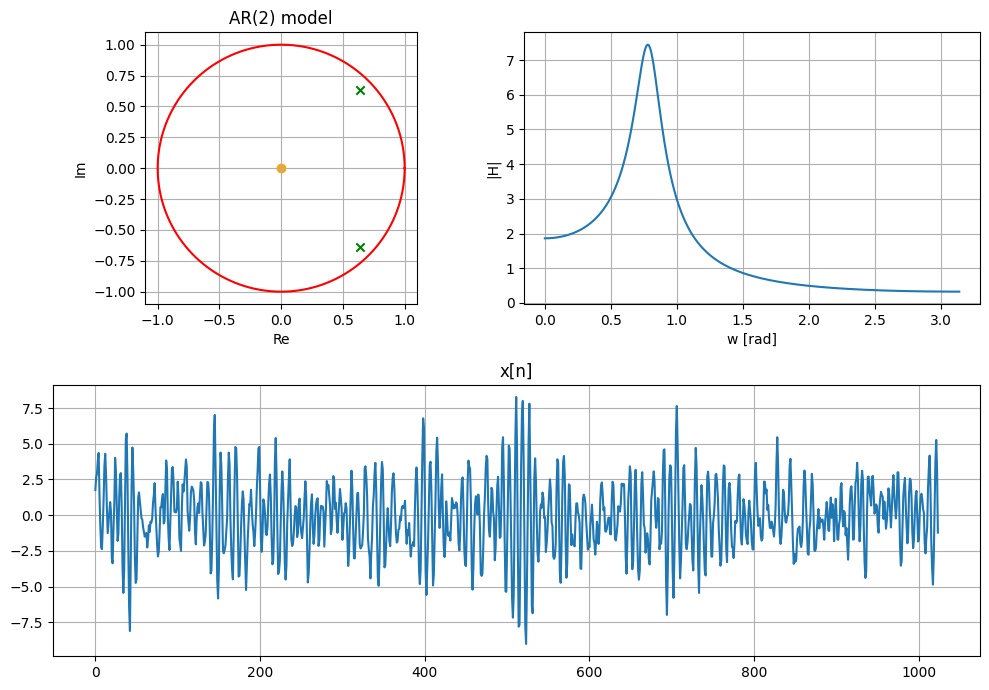

In [35]:
fig = plt.figure(figsize=(10, 7))

ax1 = fig.add_subplot(2, 2, 1)
theta = np.linspace(0, 2*np.pi, 300)
ax1.plot(np.cos(theta), np.sin(theta), 'r-')
ax1.scatter(0, 0, c='orange')
ax1.scatter(poles.real, poles.imag, marker='x', c='g')
ax1.set_title('AR(2) model')
ax1.set_xlabel('Re'); ax1.set_ylabel('Im')
ax1.set_aspect('equal')
ax1.grid(True)

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(w, np.abs(H))
ax2.set_xlabel('w [rad]'); ax2.set_ylabel('|H|')
ax2.grid(True)

ax3 = fig.add_subplot(2, 1, 2)
ax3.plot(x)
ax3.set_title('x[n]')
ax3.grid(True)

fig.tight_layout()
plt.show()

#### Ex2 : Wiener-Hopf

As it is a WSS, the coefficients can be found with the Wiener-Hopf equations. The Wiener filter is designed with the estimation done on the data.
The optimum causal linear predictor for x[n] is:

$$
\hat{x}[n] = w[1]x[n - 1] + w[2]x[n - 2]
$$

$$
\hat{x}[n] = 1.2728x[n - 1] - 0.81x[n - 2]
$$


##### Ex2.1 Design filter

- Design the prediction filter 1 step using the Wiener-Hopf equations (p=2). You will observe that the coefficients are very close to the AR(2) coefficients.:

In [36]:
p = 2
mid = N - 1
step = 1

# autocorrelation
ryy_k = np.correlate(x, x, mode='full') / N
Ry = toeplitz(ryy_k[mid : mid +p])

ry_alpha = ryy_k[mid + step : mid + step + p]
w = np.linalg.solve(Ry, ry_alpha)
E = ryy_k[mid] - np.dot(w, ry_alpha)

print(w)
print(E)

[ 1.27848692 -0.8236305 ]
0.9889740396374807


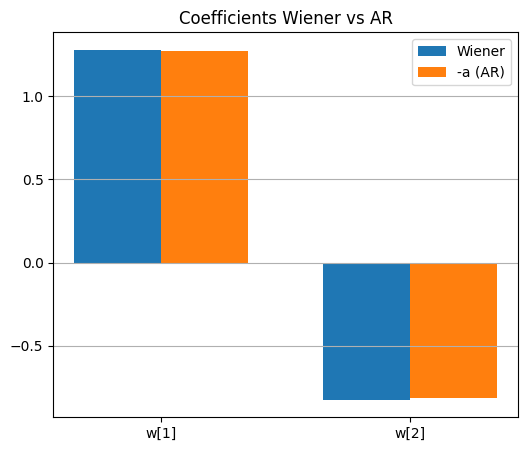

In [37]:
k = np.arange(p)              # positions [0, 1]
width = 0.35                  # largeur d'une barre

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(k - width/2, w,      width, label='Wiener')
ax.bar(k + width/2, -a[1:], width, label='-a (AR)')
ax.set_xticks(k)
ax.set_xticklabels(['w[1]', 'w[2]'])
ax.set_title('Coefficients Wiener vs AR')
ax.legend()
ax.grid(True, axis='y')
plt.show()

##### Ex2.2 Prediction

- compute the predcition error $e[n] = x[n] - \hat{x}[n]$ and plot the prediction error with the MSE.


In [38]:
x_hat = signal.lfilter(w, 1, x)
e_n = x[1:] - x_hat[:-1]        # aligne : prédire x(n) à partir des passés
mse = np.mean(e_n**2)

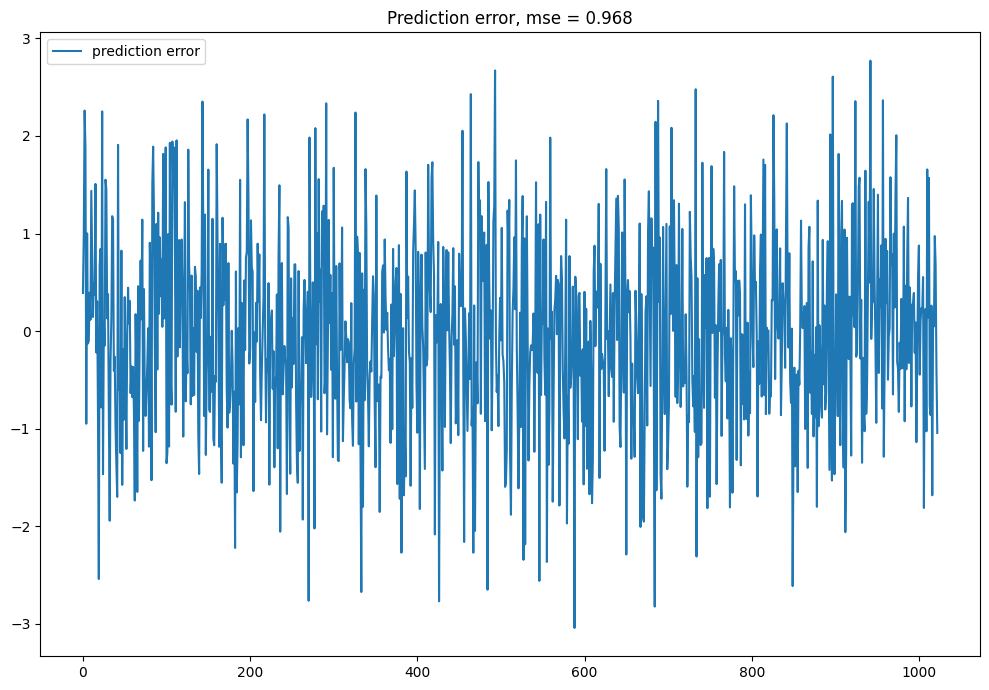

In [39]:
fig = plt.figure(figsize=(10, 7))
ax1 = fig.add_subplot(1, 1, 1)
ax1.plot(e_n, label = 'prediction error')
ax1.set_title(f"Prediction error, mse = {mse:.3}")
ax1.legend()
fig.tight_layout()
plt.show()

#### Ex3 : LMS

The predictive parameters can be also found using the LMS algorithm.

With the LMS algorithm, the predictor coefficients $w_n[k]$ are updated as follows:

$$
w_{n+1}[k] = w_n[k] + \mu\, e[n]\, x^*[n - k]
$$

##### Ex3.1 Design filter

For the design, we will compare two differents rate $\mu$ : $5\cdot 10^{-4}$ and  $1\cdot 10^{-2}$.

- Implement the function `myLMS` to compute the coefficients accross time


```python
def myLMS(x, d, mu, p):
    """
    myLMS Adaptive filtering using the Widrow-Hoff LMS algorithm.

    Parameters:
        x    : 1D array, input data to the adaptive filter
        d    : 1D array, desired output
        mu   : float, LMS step-size (update) parameter
        p : int, number of filter coefficients

    Returns:
        W : 2D array of shape (N, nord), filter coefficients over time
        e : 1D array of shape (N,), error signal over time
    """
    # your code

    return W, e

```

- Plot the coefficients of the filter accross time for the two values of $\mu$ and compare them to the Wiener filter.
- Display in a bar plot the optimal coefficients, the coefficients obtained with wiener and the last obtained with LMS for the two values of $\mu$.

In [40]:
def myLMS(x, d, mu, p):
    """
    myLMS Adaptive filtering using the Widrow-Hoff LMS algorithm.

    Parameters:
        x    : 1D array, input data to the adaptive filter
        d    : 1D array, desired output
        mu   : float, LMS step-size (update) parameter
        p : int, number of filter coefficients

    Returns:
        W : 2D array of shape (N, nord), filter coefficients over time
        e : 1D array of shape (N,), error signal over time
    """
    N = len(x)
    w = np.zeros(p)
    e = np.zeros(N)
    W = np.zeros((N,p))

    for n in range (p,N):
        x_vec = x[n-p : n][::-1]          # [x(n-1), x(n-2), ..., x(n-p)]
        d_hat = w @ x_vec                 # prédiction
        e[n]  = d[n] - d_hat              # erreur
        w     = w + mu * e[n] * x_vec     # mise à jour
        W[n]  = w                         # historique


    return W, e

In [41]:
W1, e1 = myLMS(x, x, 5e-4, 2)
W2, e2 = myLMS(x, x, 1e-2, 2)

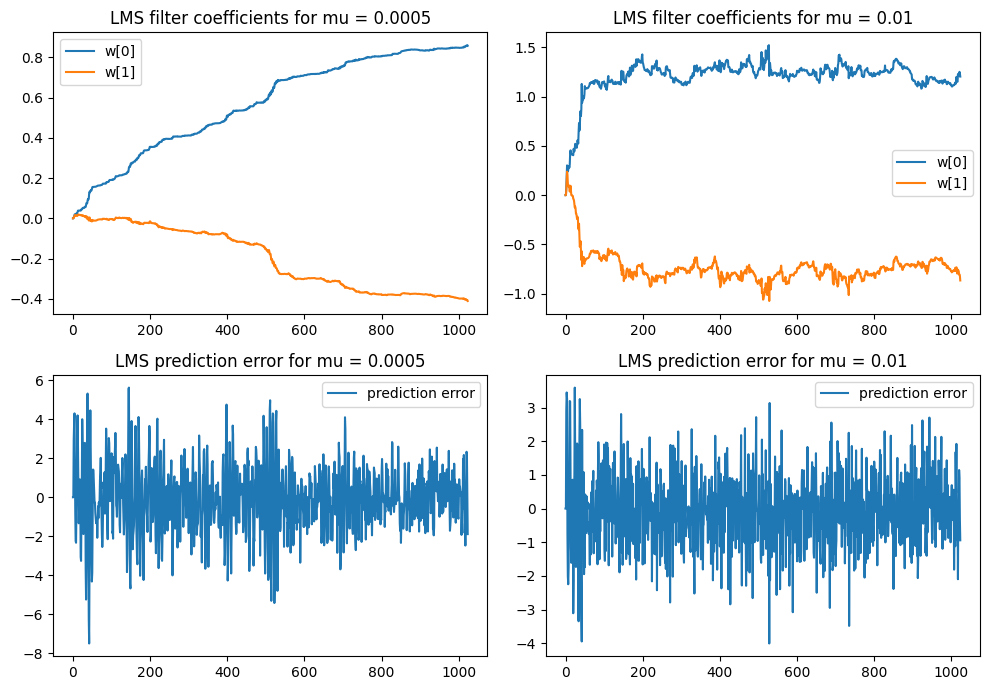

In [42]:
fig = plt.figure(figsize=(10, 7))
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(W1[:, 0], label='w[0]')
ax1.plot(W1[:, 1], label='w[1]')
ax1.set_title("LMS filter coefficients for mu = 0.0005")
ax1.legend()
fig.tight_layout()

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(W2[:, 0], label='w[0]')
ax2.plot(W2[:, 1], label='w[1]')
ax2.set_title("LMS filter coefficients for mu = 0.01")
ax2.legend()
fig.tight_layout()

ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(e1, label = 'prediction error')
ax3.set_title("LMS prediction error for mu = 0.0005")
ax3.legend()
fig.tight_layout()

ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(e2, label = 'prediction error')
ax4.set_title("LMS prediction error for mu = 0.01")
ax4.legend()
fig.tight_layout()

plt.show()

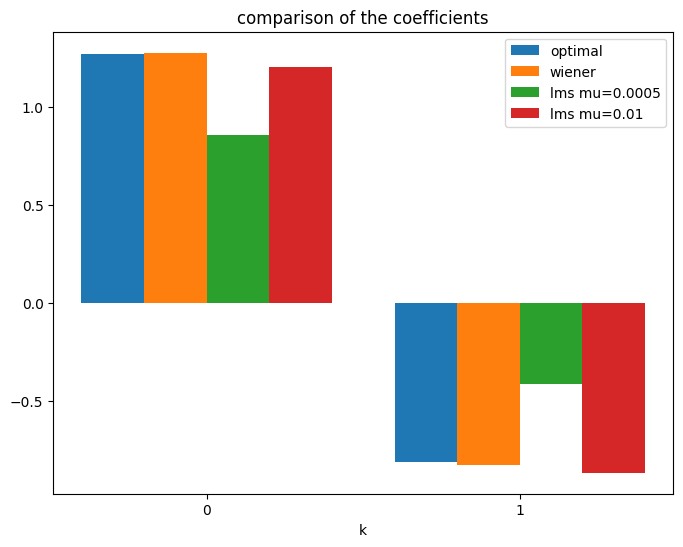

In [43]:
# Récupération des coefficients finaux
optimal_coefs = -a[1:]         # Les vrais coefficients du modèle AR(2)
wiener_coefs = w               # Calculés dans l'Ex2.1
lms_mu1_coefs = W1[-1]         # Dernière itération du LMS avec mu=0.0005
lms_mu2_coefs = W2[-1]         # Dernière itération du LMS avec mu=0.01

# Configuration de l'axe des abscisses pour les 4 barres
k_indices = np.arange(2)       # positions 0 et 1
width = 0.2                    # largeur de chaque barre

fig, ax = plt.subplots(figsize=(8, 6))

# Création des barres avec décalage pour ne pas les superposer
ax.bar(k_indices - 1.5*width, optimal_coefs, width, label='optimal')
ax.bar(k_indices - 0.5*width, wiener_coefs, width, label='wiener')
ax.bar(k_indices + 0.5*width, lms_mu1_coefs, width, label='lms mu=0.0005')
ax.bar(k_indices + 1.5*width, lms_mu2_coefs, width, label='lms mu=0.01')

# Ajout des labels et de la légende comme sur ton image
ax.set_xticks(k_indices)
ax.set_xticklabels(['0', '1'])
ax.set_xlabel('k')
ax.set_title('comparison of the coefficients')
ax.legend()

plt.show()

##### Ex3.2 Performance Surface

Finally, a performance surface is drawn with the two rates. It is showing the path realized on the error surface by the optimizer.

- Implement the function `compute_prediction_mse` to compute the performance surface and plot it.

```python
def compute_prediction_mse(x,w):
    """
    Computes the prediction MSE for a given filter w and input signal x.

    Parameters:
        x : 1D array, input signal
        w : 1D array, filter coefficients

    Returns:
        mse : float, mean square error of the prediction
    """
    # your code
    return mse
```

In [44]:
def compute_prediction_mse(x,w):
    """
    Computes the prediction MSE for a given filter w and input signal x.

    Parameters:
        x : 1D array, input signal
        w : 1D array, filter coefficients

    Returns:
        mse : float, mean square error of the prediction
    """
    x_hat = signal.lfilter(w, 1, x)
    e_n = x[p:] - x_hat[p-1:-1]       # aligne : prédire x(n) à partir des passés
    mse = np.mean(e_n**2)
    
    return mse

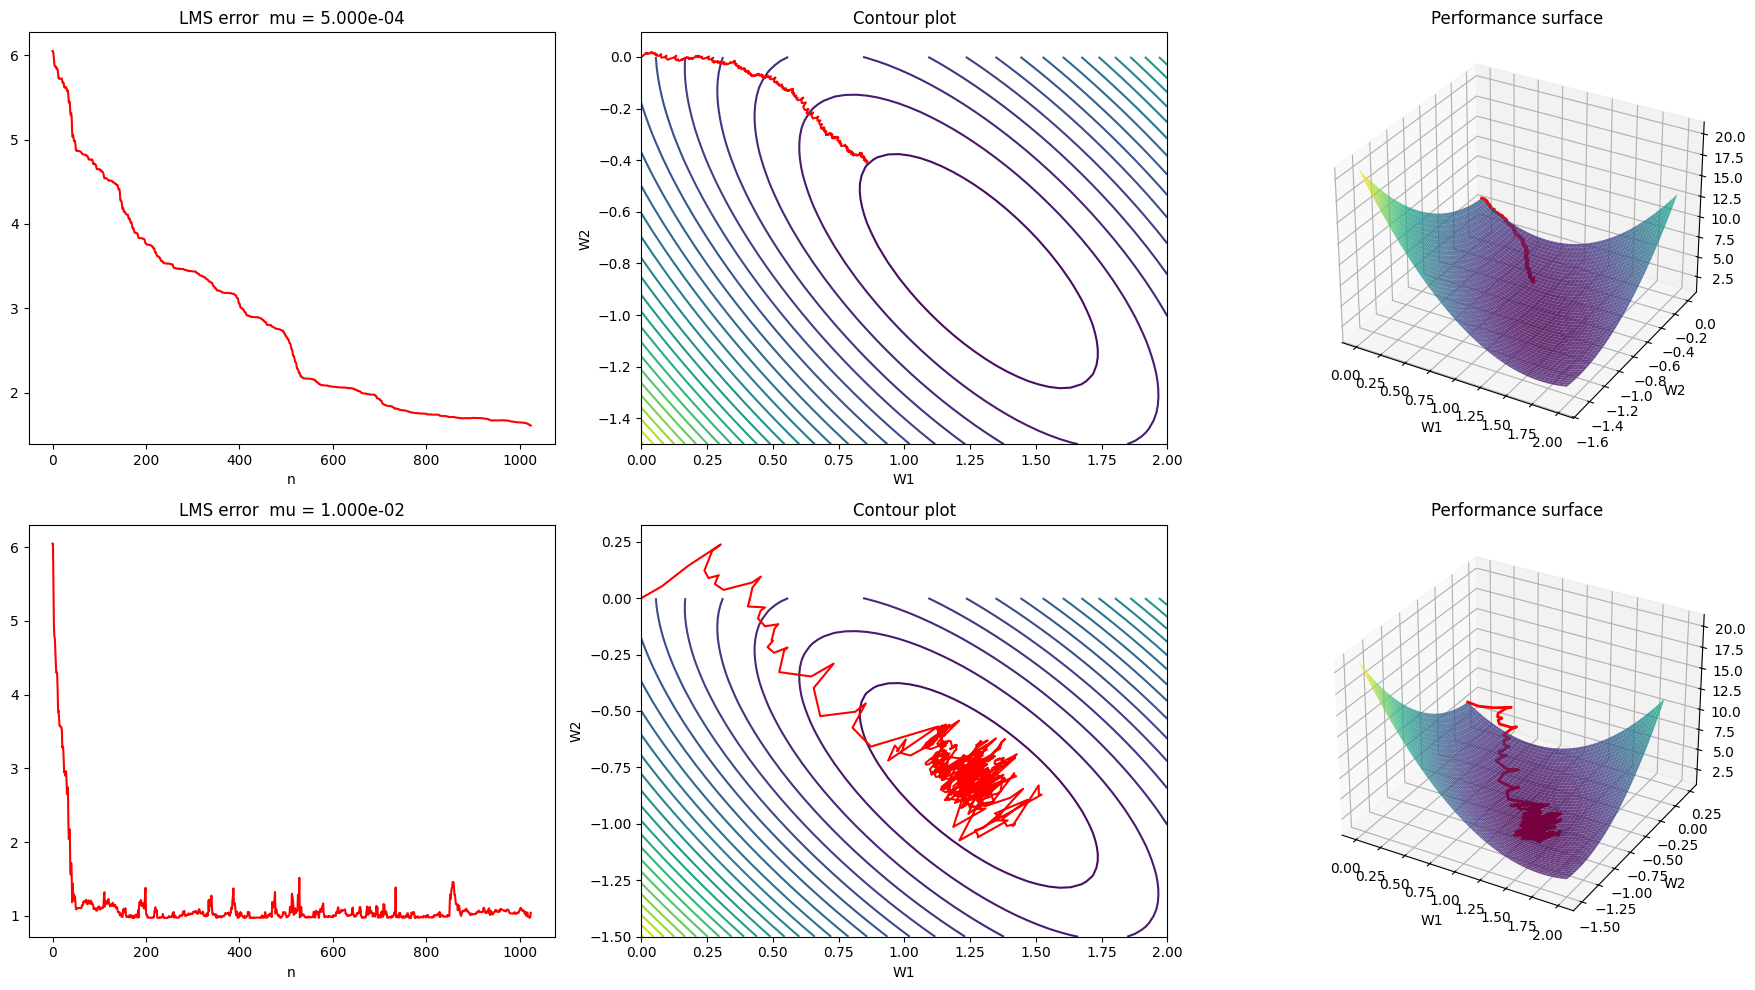

In [45]:
# 1. Définition des bornes pour la surface d'erreur (basées sur les valeurs attendues)
w1_vals = np.linspace(0.0, 2.0, 50)
w2_vals = np.linspace(-1.5, 0.0, 50)
W1_grid, W2_grid = np.meshgrid(w1_vals, w2_vals)
MSE_grid = np.zeros_like(W1_grid)

# Calcul du MSE pour chaque point de la grille
for i in range(W1_grid.shape[0]):
    for j in range(W1_grid.shape[1]):
        w_tmp = np.array([W1_grid[i, j], W2_grid[i, j]])
        MSE_grid[i, j] = compute_prediction_mse(x, w_tmp)

# 2. Évaluation de la fonction de coût (MSE) tout au long des trajectoires LMS
# On calcule l'erreur théorique pour chaque jeu de poids à l'instant n
J1 = np.array([compute_prediction_mse(x, w) for w in W1])
J2 = np.array([compute_prediction_mse(x, w) for w in W2])

# 3. Création de la figure (2 lignes, 3 colonnes)
fig = plt.figure(figsize=(18, 10))

# --- LIGNE 1 : LMS avec mu = 5e-4 ---

# Plot 1: Courbe d'erreur
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(J1, 'r')
ax1.set_title('LMS error  mu = 5.000e-04')
ax1.set_xlabel('n')

# Plot 2: Contour plot
ax2 = fig.add_subplot(2, 3, 2)
ax2.contour(W1_grid, W2_grid, MSE_grid, levels=25, cmap='viridis')
ax2.plot(W1[:, 0], W1[:, 1], 'r') # Trajectoire des poids
ax2.set_title('Contour plot')
ax2.set_xlabel('W1')
ax2.set_ylabel('W2')

# Plot 3: 3D Performance surface
ax3 = fig.add_subplot(2, 3, 3, projection='3d')
ax3.plot_surface(W1_grid, W2_grid, MSE_grid, cmap='viridis', alpha=0.8, edgecolor='none')
ax3.plot(W1[:, 0], W1[:, 1], J1, 'r', linewidth=2) # Trajectoire 3D
ax3.set_title('Performance surface')
ax3.set_xlabel('W1')
ax3.set_ylabel('W2')

# --- LIGNE 2 : LMS avec mu = 1e-2 ---

# Plot 4: Courbe d'erreur
ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(J2, 'r')
ax4.set_title('LMS error  mu = 1.000e-02')
ax4.set_xlabel('n')

# Plot 5: Contour plot
ax5 = fig.add_subplot(2, 3, 5)
ax5.contour(W1_grid, W2_grid, MSE_grid, levels=25, cmap='viridis')
ax5.plot(W2[:, 0], W2[:, 1], 'r')
ax5.set_title('Contour plot')
ax5.set_xlabel('W1')
ax5.set_ylabel('W2')

# Plot 6: 3D Performance surface
ax6 = fig.add_subplot(2, 3, 6, projection='3d')
ax6.plot_surface(W1_grid, W2_grid, MSE_grid, cmap='viridis', alpha=0.8, edgecolor='none')
ax6.plot(W2[:, 0], W2[:, 1], J2, 'r', linewidth=2)
ax6.set_title('Performance surface')
ax6.set_xlabel('W1')
ax6.set_ylabel('W2')

plt.tight_layout()
plt.show()

#### Ex4 : NLMS
The predictive parameters can be also found using the normalized LMS algorithm also called NLMS.

With the NLMS algorithm, the predictor coefficients $w_n[k]$ are updated as follows:

$$
w_{n+1}[k] = w_n[k] + \beta \, \frac{x^*[n - k]}{\varepsilon + x^2[n - 1] + x^2[n - 2]} \, e[n]
$$

##### Ex4.1 Design filter

- Implement the function `myNLMS` to compute the coefficients accross time
- Comupte the coefficients with the NLMS algorithm and plot them for $\beta = 0.02$ and $\beta = 0.005$ and with $\varepsilon = 1e-4$
- Compare with the coefficients obtained with the Wiener filter and the LMS algorithm

```python
def myNLMS(x, d, beta, p, epsilon=1e-6):
    """
    myNLMS Adaptive filtering using the normalized LMS algorithm.

    Parameters:
        x : 1D array, input data to the adaptive filter
        d : 1D array, desired output
        beta : float, NLMS step-size (update) parameter
        p : int, number of filter coefficients
        epsilon : float, small constant to avoid division by zero

    Returns:
        W : 2D array of shape (N, nord), filter coefficients over time
        e : 1D array of shape (N,), error signal over time
    """
    # your code

    return W, e
```

In [46]:
def myNLMS(x, d, beta, p, epsilon=1e-6):
    """
    myNLMS Adaptive filtering using the normalized LMS algorithm.

    Parameters:
        x : 1D array, input data to the adaptive filter
        d : 1D array, desired output
        beta : float, NLMS step-size (update) parameter
        p : int, number of filter coefficients
        epsilon : float, small constant to avoid division by zero

    Returns:
        W : 2D array of shape (N, nord), filter coefficients over time
        e : 1D array of shape (N,), error signal over time
    """
    N = len(x)
    w = np.zeros(p)
    e = np.zeros(N)
    W = np.zeros((N,p))

    for n in range (p,N):
        x_vec = x[n-p : n][::-1]          # [x(n-1), x(n-2), ..., x(n-p)]
        d_hat = w @ x_vec                 # prédiction
        e[n]  = d[n] - d_hat              # erreur
        #w     = w + mu * e[n] * x_vec     # mise à jour
        w = w + beta * e[n] * x_vec / (epsilon + x_vec @ x_vec)    # mise à jour
        W[n]  = w                         # historique
    return W, e

In [47]:
W1, e1 = myNLMS(x, x, 0.02, 2)
W2, e2 = myNLMS(x, x, 0.005, 2)

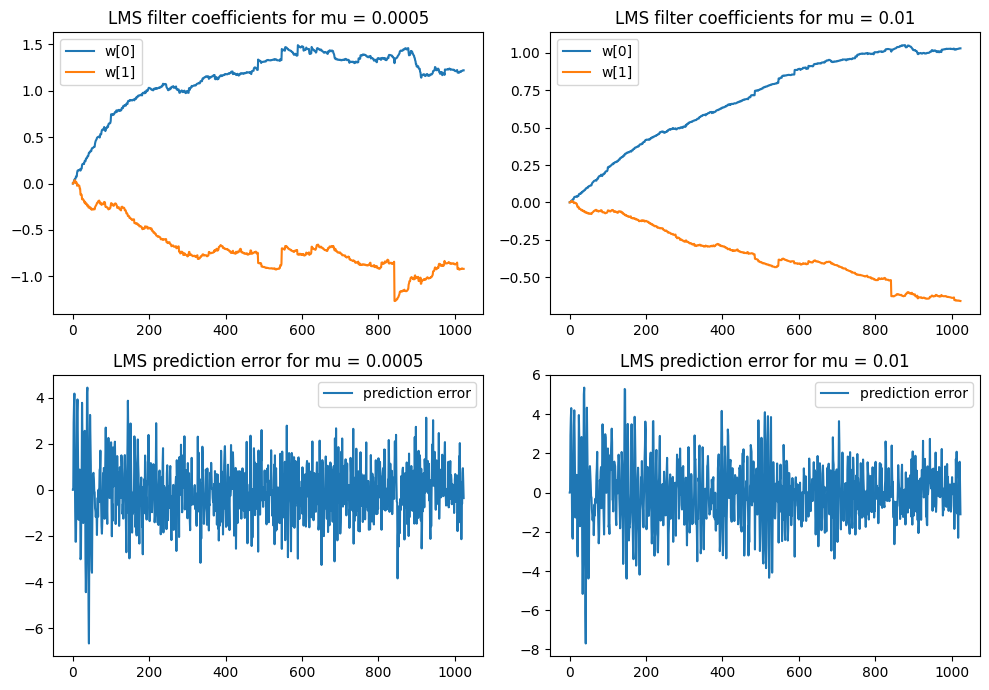

In [48]:
fig = plt.figure(figsize=(10, 7))
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(W1[:, 0], label='w[0]')
ax1.plot(W1[:, 1], label='w[1]')
ax1.set_title("LMS filter coefficients for mu = 0.0005")
ax1.legend()
fig.tight_layout()

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(W2[:, 0], label='w[0]')
ax2.plot(W2[:, 1], label='w[1]')
ax2.set_title("LMS filter coefficients for mu = 0.01")
ax2.legend()
fig.tight_layout()

ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(e1, label = 'prediction error')
ax3.set_title("LMS prediction error for mu = 0.0005")
ax3.legend()
fig.tight_layout()

ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(e2, label = 'prediction error')
ax4.set_title("LMS prediction error for mu = 0.01")
ax4.legend()
fig.tight_layout()

plt.show()

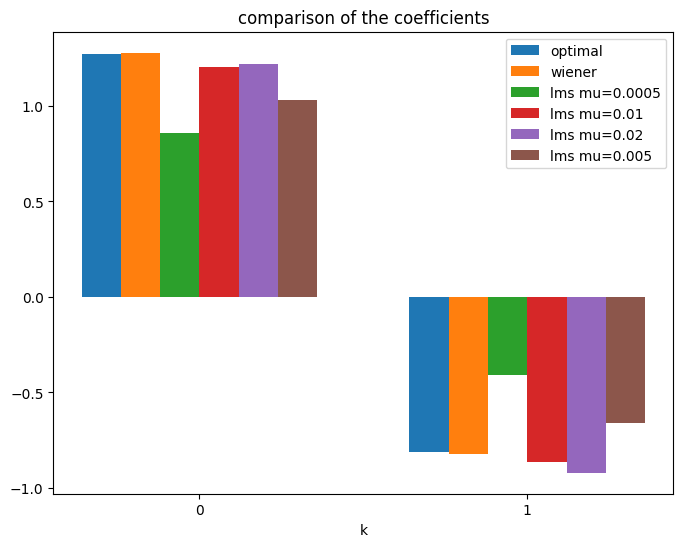

In [50]:
# Récupération des coefficients finaux
optimal_coefs = -a[1:]         # Vrais coefficients du modèle AR(2)
wiener_coefs = w               # Calculés dans l'Ex2.1
nlms_mu1_coefs = W1[-1]         # Dernière itération du LMS avec mu=0.0005
nlms_mu2_coefs = W2[-1]         # Dernière itération du LMS avec mu=0.01
# Assure-toi d'utiliser les bonnes variables si tu as tout compilé dans le même script
lms_mu1_coefs = lms_mu1_coefs # Dernière itération du LMS avec mu=0.0005
lms_mu2_coefs = lms_mu2_coefs # Dernière itération du LMS avec mu=0.01
nlms_b1_coefs = nlms_mu1_coefs# Dernière itération du NLMS avec beta=0.02
nlms_b2_coefs = nlms_mu2_coefs    # Dernière itération du NLMS avec beta=0.005

# Configuration de l'axe des abscisses pour 6 barres
k_indices = np.arange(2)       # positions 0 et 1
width = 0.12                   # largeur réduite pour faire tenir les 6 barres

fig, ax = plt.subplots(figsize=(8, 6))

# Création des barres avec les décalages appropriés
ax.bar(k_indices - 2.5*width, optimal_coefs, width, label='optimal')
ax.bar(k_indices - 1.5*width, wiener_coefs, width, label='wiener')
ax.bar(k_indices - 0.5*width, lms_mu1_coefs, width, label='lms mu=0.0005')
ax.bar(k_indices + 0.5*width, lms_mu2_coefs, width, label='lms mu=0.01')
# Les labels reprennent l'image, bien que ce soit du NLMS
ax.bar(k_indices + 1.5*width, nlms_b1_coefs, width, label='lms mu=0.02') 
ax.bar(k_indices + 2.5*width, nlms_b2_coefs, width, label='lms mu=0.005')

# Ajout des labels, du titre et de la légende
ax.set_xticks(k_indices)
ax.set_xticklabels(['0', '1'])
ax.set_xlabel('k')
ax.set_title('comparison of the coefficients')
ax.legend()

plt.show()